# 1. Executive Summary

This project applied unsupervised machine learning techniques to segment retail customers based on purchasing behavior using transactional e-commerce data.

The analysis explored multiple clustering approaches, including KMeans, Agglomerative Clustering, and Gaussian Mixture Models. After comparative evaluation, KMeans with four clusters was selected as the optimal solution due to its strong balance between interpretability, cluster separation, and business applicability. Although k=3 achieved a slightly higher silhouette score, k=4 provided more actionable and business-relevant customer segmentation.

The final segmentation identified four distinct customer groups with significantly different purchasing patterns, enabling actionable business strategies focused on customer retention, loyalty, and revenue optimization.

# 2. Business Problem

Understanding customer purchasing behavior is essential for designing effective marketing strategies, improving customer retention, and maximizing revenue.

The primary objective of this project is to identify meaningful customer segments using unsupervised learning techniques in order to support data-driven business decisions.

# 3. Dataset Description

The dataset used in this project contains transactional records from a UK-based online retail company between 2009 and 2011.

The dataset includes customer purchases, product information, transaction dates, quantities, prices, and customer identifiers.

After preprocessing and cleaning, customer-level features were engineered using RFM analysis and additional behavioral metrics:

- Recency
- Frequency
- Monetary Value
- Average Order Value
- Basket Size
- Customer Lifetime

The final analytical dataset contains 5,878 unique customers.

# 4. Methodology

The project followed a structured unsupervised learning workflow:

1. Data Cleaning
   - Removed missing customer identifiers
   - Filtered cancelled transactions
   - Removed invalid quantities and prices

2. Feature Engineering
   - Created RFM metrics
   - Added Average Order Value
   - Added Basket Size
   - Added Customer Lifetime

3. Data Transformation
   - Applied logarithmic transformation to reduce skewness
   - Standardized features using StandardScaler

4. Dimensionality Reduction
   - Applied Principal Component Analysis (PCA) for visualization purposes

5. Clustering Models
   - KMeans
   - Agglomerative Clustering
   - Gaussian Mixture Models

6. Model Evaluation
   - Silhouette Score
   - Calinski-Harabasz Index
   - Davies-Bouldin Index   

# 5. Model Comparison

model_results = pd.DataFrame({

    "Model": [
        "KMeans",
        "Agglomerative",
        "Gaussian Mixture"
    ],

    "Silhouette Score": [
        0.290116,
        0.260756,
        0.162694
    ],

    "Calinski-Harabasz": [
        2560.133805,
        1996.736476,
        1370.285207
    ],

    "Davies-Bouldin": [
        1.163931,
        1.130575,
        1.955225
    ]
})

model_results

KMeans with four clusters was selected as the final model due to its superior balance between cluster separation, interpretability, and business applicability.

Although Agglomerative Clustering achieved a slightly lower Davies-Bouldin score, KMeans provided stronger overall performance and more actionable customer segments.

# 6. Final Customer Segments

In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

segments = pd.read_csv(
    r"C:\Users\usuario\Desktop\Retail Customer Intelligence Customer Segmentation through Unsupervised Machine Learning\data\processed\customer_segments.csv",
    index_col=0
)

segments.head()

,Recency,Frequency,Monetary,AvgOrderValue,BasketSize,CustomerLifetime,Cluster
Customer ID,,,,,,,
12346.0,5.789960,2.564949,11.258774,7.732839,7.689761,5.993961,2
12347.0,1.098612,2.197225,8.636632,3.146997,2.638210,5.998937,0
12348.0,4.330733,1.791759,7.611051,3.703671,3.992970,5.894403,2
12349.0,2.995732,1.609438,8.396085,3.269827,2.330200,6.347389,0
12350.0,5.739793,0.693147,5.815324,3.028712,2.532763,0.000000,1


# 7. Cluster Size Visualization

In [8]:
cluster_counts = (
    segments["Cluster"]
    .value_counts()
    .sort_index()
)

C:\Users\usuario\AppData\Local\Temp\ipykernel_2244\1439645282.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


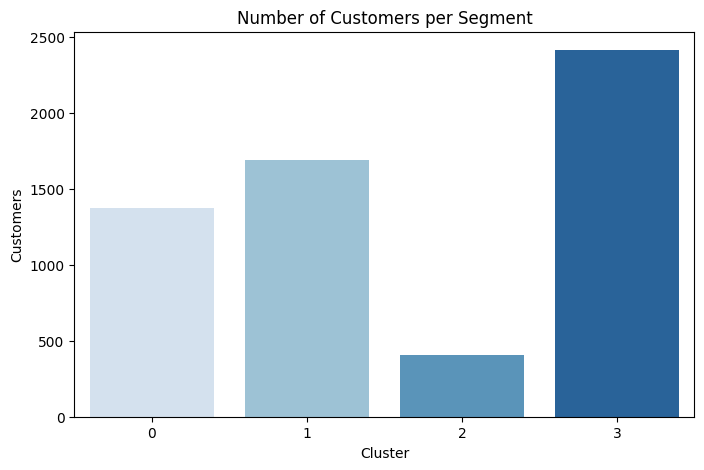

In [9]:
plt.figure(figsize=(8,5))

sns.barplot(
    palette="Blues",
    x=cluster_counts.index,
    y=cluster_counts.values
)

plt.title("Number of Customers per Segment")

plt.xlabel("Cluster")

plt.ylabel("Customers")

plt.show()

# 8. Cluster Profile Heatmap

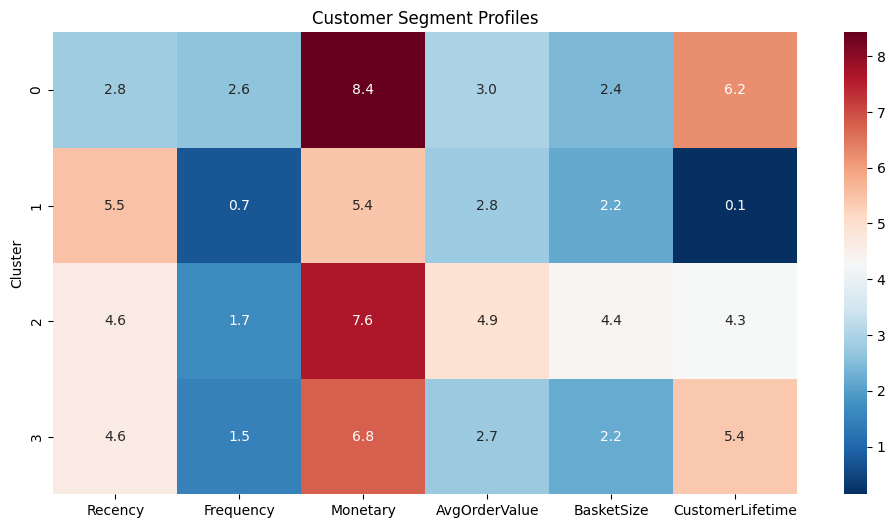

In [10]:
cluster_profile = (
    segments
    .groupby("Cluster")
    .mean(numeric_only=True)
)

plt.figure(figsize=(12,6))

sns.heatmap(
    cluster_profile,
    annot=True,
    fmt=".1f",
    cmap="RdBu_r"
)

plt.title("Customer Segment Profiles")

plt.show()

## Original-Scale Cluster Profiles

To improve business interpretability, the following table presents customer segment averages in their original scale.


In [ ]:
cluster_profile_original = (
    segments
    .groupby("Cluster")
    .mean(numeric_only=True)
    .round(2)
)

cluster_profile_original


# 9. Segment Interpretation

Cluster 0 — High-Value Loyal Customers (Interpreted Segment)

This segment was identified as a high-value customer group characterized by frequent purchases, recent activity, and strong monetary contribution.

Based on these behavioral patterns, this cluster was interpreted as a VIP-like customer segment, representing customers with high potential business value.

Cluster 1 — Low-Engagement / Churn Risk Customers (Interpreted Segment)

This cluster represents customers with low purchase frequency and long periods of inactivity.

The segment was interpreted as a churn-risk group based on reduced engagement patterns.

Cluster 2 — High-Value Bulk Buyers (Interpreted Segment)

This group presents high monetary contribution, large basket sizes, and elevated average order values.

These characteristics suggest a purchasing behavior associated with high-volume or bulk buying patterns.

Cluster 3 — Regular Customers (Interpreted Segment)

This segment represents customers with moderate and consistent purchasing behavior.

The cluster was interpreted as the stable customer base of the business.

# 10. Business Recommendations

Based on the identified customer segments, the following business strategies are recommended:

- Develop VIP loyalty programs for high-value customers.
- Launch reactivation campaigns targeting inactive customers.
- Create personalized offers for bulk buyers.
- Implement cross-selling and upselling strategies for regular customers.
- Prioritize retention strategies for the most profitable customer segments.

# 11. Limitations

# 12. Future Work

## Customer Segment Distribution

The following visualization highlights the monetary distribution across customer segments.


C:\Users\usuario\AppData\Local\Temp\ipykernel_2244\1234895505.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


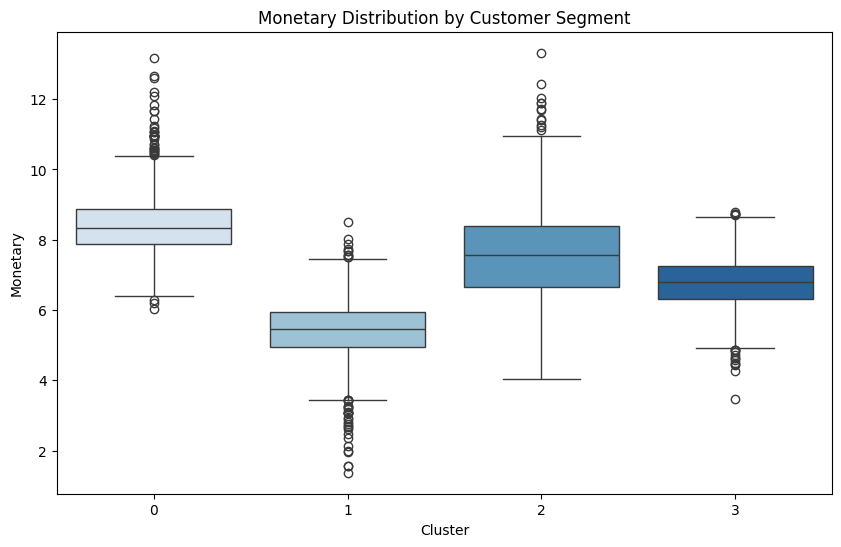

In [11]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="Cluster",
    y="Monetary",
    data=segments,
    palette="Blues"
)

plt.title("Monetary Distribution by Customer Segment")

plt.show()


## PCA Cluster Visualization

Principal Component Analysis (PCA) is used below to visualize customer segments in a two-dimensional space.


In [12]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

features = segments.drop(columns=["Cluster"])

scaled_features = StandardScaler().fit_transform(features)

pca = PCA(n_components=2)

pca_result = pca.fit_transform(scaled_features)

pca_df = pd.DataFrame(
    pca_result,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = segments["Cluster"].values


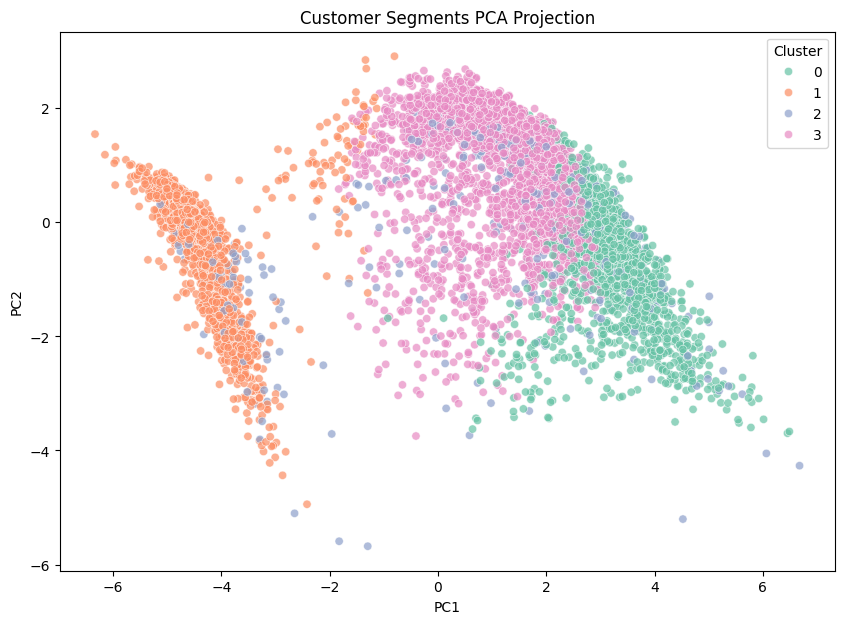

In [13]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="Cluster",
    data=pca_df,
    palette="Set2",
    alpha=0.7
)

plt.title("Customer Segments PCA Projection")

plt.show()


# 11. Limitations

This analysis presents several limitations:

- The dataset only reflects historical transactional behavior and does not include demographic or behavioral customer information.
- Clustering performance depends heavily on preprocessing decisions and selected features.
- External economic or seasonal factors influencing customer behavior are not represented.
- The dataset originates from a single retail company, which may limit generalizability.


# 12. Future Work

Future improvements could include:

- Incorporating demographic and geographic variables.
- Exploring advanced dimensionality reduction techniques such as UMAP.
- Testing alternative clustering algorithms such as DBSCAN.
- Evaluating cluster stability using bootstrap sampling and multiple random seeds.
- Developing automated customer segmentation pipelines.
- Deploying the solution into a production environment for real-time customer classification.


## Key Findings

- Four distinct customer segments were successfully identified.
- A small group of VIP customers generates disproportionately high revenue.
- A large percentage of customers exhibit low engagement and high churn risk.
- Customer purchasing behaviors vary significantly across segments.
- The segmentation approach provides actionable insights for personalized marketing strategies.


## Additional Analytical Considerations

Future iterations of this project could include:

- Cluster stability analysis across multiple random seeds.
- Bootstrap validation for segmentation robustness.
- Integration of demographic and geographic customer attributes.
- Advanced behavioral segmentation techniques.


# 13. Final Conclusion
# 13. Final Conclusion

This project successfully applied unsupervised machine learning techniques to identify meaningful customer segments within a retail e-commerce dataset.

The final KMeans clustering model identified four distinct customer groups with significantly different purchasing behaviors and business value profiles.

The analysis demonstrates how customer segmentation can support data-driven marketing strategies, improve customer retention, and optimize revenue generation.

Beyond the technical implementation, the project highlights the importance of combining machine learning with business understanding to generate actionable insights.

C:\Users\usuario\AppData\Local\Temp\ipykernel_2244\1234895505.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


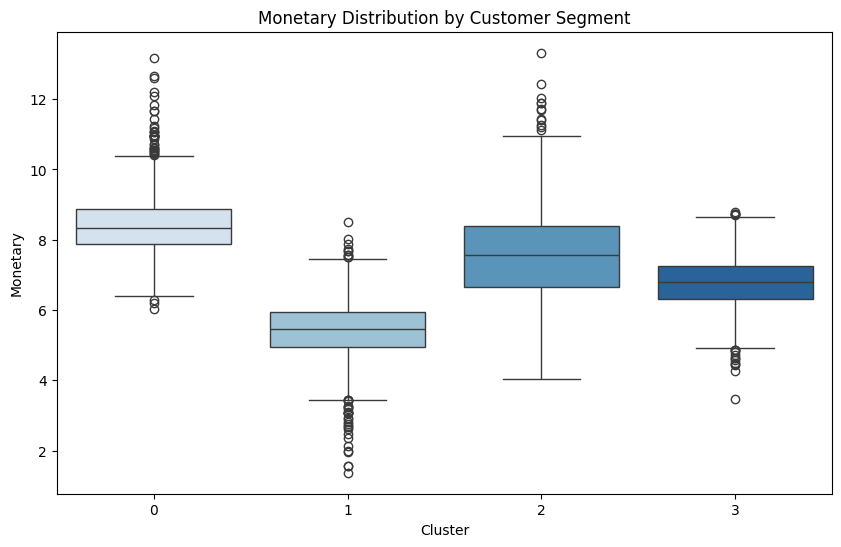

In [14]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="Cluster",
    y="Monetary",
    data=segments,
    palette="Blues"
)

plt.title("Monetary Distribution by Customer Segment")

plt.show()


In [15]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

features = segments.drop(columns=["Cluster"])

scaled_features = StandardScaler().fit_transform(features)

pca = PCA(n_components=2)

pca_result = pca.fit_transform(scaled_features)

pca_df = pd.DataFrame(
    pca_result,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = segments["Cluster"].values


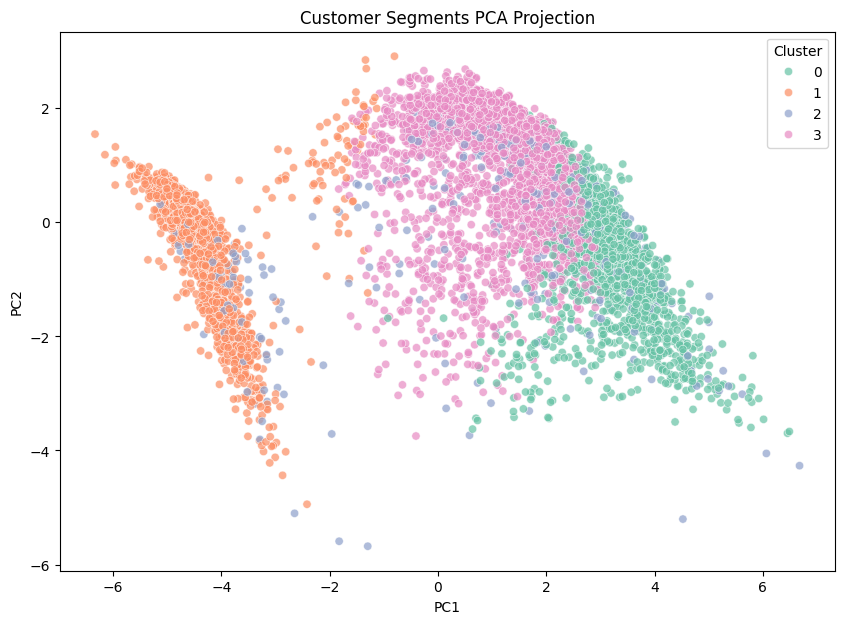

In [16]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="Cluster",
    data=pca_df,
    palette="Set2",
    alpha=0.7
)

plt.title("Customer Segments PCA Projection")

plt.show()
